In [5]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

np.random.seed(42)

cities = [
    "Delhi", "Mumbai", "Bengaluru", "Chennai", "Kolkata", 
    "Hyderabad", "Pune", "Ahmedabad", "Jaipur", "Lucknow"
]

num_samples = len(cities)

sunlight_hours = np.round(np.random.uniform(4.5, 6.0, num_samples), 2)
tariff_inr = np.round(np.random.uniform(6.5, 9.5, num_samples), 2)
efficiency = np.round(np.random.uniform(0.15, 0.20, num_samples), 2)
avg_temp_c = np.round(np.random.uniform(24.0, 34.0, num_samples), 1)

data = {
    "City": cities,
    "Avg_Daily_Sunlight_Hours": sunlight_hours,
    "Electricity_Tariff_INR": tariff_inr,
    "Avg_Solar_Efficiency": efficiency,
    "Avg_Annual_Temp_C": avg_temp_c
}

df_solar = pd.DataFrame(data)


In [4]:
df_solar.to_csv("city_solar_irradiance.csv", index=False)

print("Dataset generated and saved to data/city_solar_irradiance.csv successfully!")
print("\nFirst 5 rows of generated dataset:")
print(df_solar.head())

Dataset generated and saved to data/city_solar_irradiance.csv successfully!

First 5 rows of generated dataset:
        City  Avg_Daily_Sunlight_Hours  Electricity_Tariff_INR  \
0      Delhi                      5.06                    6.56   
1     Mumbai                      5.93                    9.41   
2  Bengaluru                      5.60                    9.00   
3    Chennai                      5.40                    7.14   
4    Kolkata                      4.73                    7.05   

   Avg_Solar_Efficiency  Avg_Annual_Temp_C  
0                  0.18               30.1  
1                  0.16               25.7  
2                  0.16               24.7  
3                  0.17               33.5  
4                  0.17               33.7  


=== PIPELINE OUTPUT ===
ANALYSIS REPORT SOLAR PROSPECTING
    Detected 2 primary rooftop structures in the selected sector.
    Total rooftop coverage measures approximately 5179.12 sq meters.
    Shadow obstructions account for roughly 659.69 sq meters.
    Net usable area suitable for solar panel installation is 4519.44 sq meters.
    Estimated annual solar power generation potential: 122024.8 kWh.
    Projected financial savings per year: INR 976198.50.

[NLP Processing] Top keywords extracted from report:
['ANALYSIS', 'REPORT', 'SOLAR', 'PROSPECTING', 'Detected', '2', 'primary', 'rooftop', 'structures', 'selected', 'sector', 'Total']


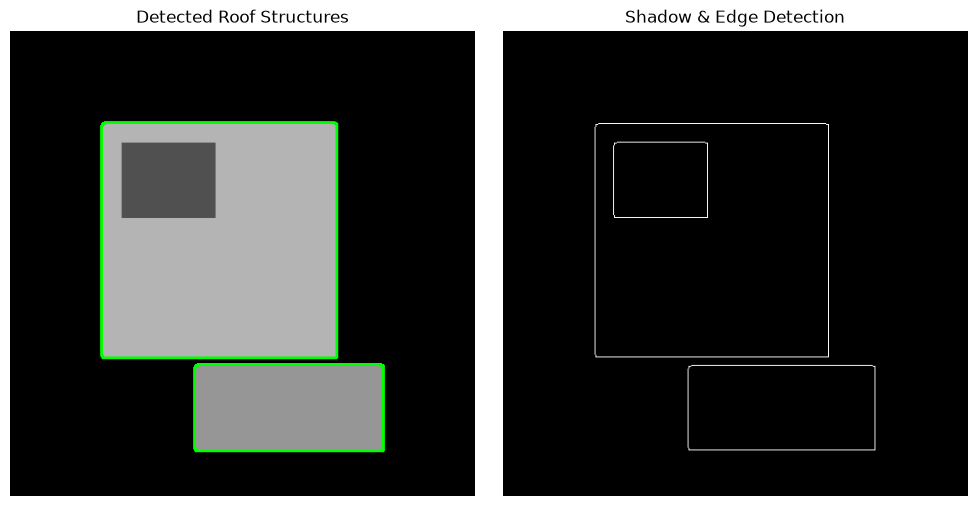

In [6]:


try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

def process_rooftop_solar(image_path, meters_per_pixel=0.25):
    img = cv2.imread(image_path)
    if img is None:
        img = np.zeros((500, 500, 3), dtype=np.uint8)
        cv2.rectangle(img, (100, 100), (350, 350), (180, 180, 180), -1)
        cv2.rectangle(img, (120, 120), (220, 200), (80, 80, 80), -1) 
        cv2.rectangle(img, (200, 360), (400, 450), (150, 150, 150), -1)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    
    edges = cv2.Canny(blur, 50, 150)
    
    kernel = np.ones((3,3), np.uint8)
    dilated = cv2.dilate(edges, kernel, iterations=1)
    
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    output_img = img.copy()
    total_rooftop_area_px = 0
    total_shadow_area_px = 0
    valid_roof_count = 0
    
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    lower_shadow = np.array([0, 0, 0])
    upper_shadow = np.array([180, 255, 100])
    shadow_mask = cv2.inRange(hsv, lower_shadow, upper_shadow)
    
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area > 1000: 
            valid_roof_count += 1
            total_rooftop_area_px += area
            
            cv2.drawContours(output_img, [cnt], -1, (0, 255, 0), 2)
            
            mask = np.zeros(gray.shape, dtype=np.uint8)
            cv2.drawContours(mask, [cnt], -1, 255, -1)
            
            roof_shadow = cv2.bitwise_and(shadow_mask, shadow_mask, mask=mask)
            total_shadow_area_px += cv2.countNonZero(roof_shadow)

    sqm_per_pixel = meters_per_pixel ** 2
    total_roof_sqm = total_rooftop_area_px * sqm_per_pixel
    shadow_sqm = total_shadow_area_px * sqm_per_pixel
    usable_area_sqm = max(0, total_roof_sqm - shadow_sqm)
    
    annual_kwh = usable_area_sqm * 150 * 0.18
    annual_savings_inr = annual_kwh * 8.0

    summary_raw = f"""
    ANALYSIS REPORT SOLAR PROSPECTING
    Detected {valid_roof_count} primary rooftop structures in the selected sector.
    Total rooftop coverage measures approximately {total_roof_sqm:.2f} sq meters.
    Shadow obstructions account for roughly {shadow_sqm:.2f} sq meters.
    Net usable area suitable for solar panel installation is {usable_area_sqm:.2f} sq meters.
    Estimated annual solar power generation potential: {annual_kwh:.1f} kWh.
    Projected financial savings per year: INR {annual_savings_inr:.2f}.
    """

    tokens = word_tokenize(summary_raw)
    stop_w = set(stopwords.words('english'))
    filtered_tokens = [w for w in tokens if w.isalnum() and w.lower() not in stop_w]
    
    print("=== PIPELINE OUTPUT ===")
    print(summary_raw.strip())
    print("\n[NLP Processing] Top keywords extracted from report:")
    print(filtered_tokens[:12])

    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.title("Detected Roof Structures")
    plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    
    plt.subplot(1, 2, 2)
    plt.title("Shadow & Edge Detection")
    plt.imshow(edges, cmap="gray")
    plt.axis("off")
    
    plt.tight_layout()
    plt.show()

process_rooftop_solar("satellite_sample.jpg")